In [ ]:
#step 1: import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Titanic.csv to Titanic.csv


In [ ]:
#step 2 : load dataset

df = pd.read_csv("Titanic.csv")
df.head(4)
df.tail(6)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
908,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
909,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
910,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
911,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
912,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q
913,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q


In [ ]:
a=df.select_dtypes(include="object")
b=df.select_dtypes(exclude="object")

print("null value count after cleaning:",df.isnull().sum())

for i in a:
  df[i] = df[i].fillna(df[i].mode()[0])

for i in b:
  df[i] = df[i].fillna(df[i].mean())

print("null value count after cleaning:",df.isnull().sum())


null value count after cleaning: Survived    0
Pclass      0
Name        1
Sex         1
Age         1
SibSp       0
Parch       0
Ticket      1
Fare        1
Embarked    1
dtype: int64
null value count after cleaning: Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


In [ ]:
#step 3: data set information
df.info()
df.tail()
print("duplicate value count before cleaning:\n",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("duplicate value count after cleaning:",df.duplicated().sum())
print("isnull value count after cleaning:",df.isnull().sum())
df.dropna(inplace=True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 914 entries, 0 to 913
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  914 non-null    int64  
 1   Pclass    914 non-null    int64  
 2   Name      914 non-null    object 
 3   Sex       914 non-null    object 
 4   Age       914 non-null    float64
 5   SibSp     914 non-null    int64  
 6   Parch     914 non-null    int64  
 7   Ticket    914 non-null    object 
 8   Fare      914 non-null    float64
 9   Embarked  914 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 71.5+ KB
duplicate value count before cleaning:
 23
duplicate value count after cleaning: 0
isnull value count after cleaning: Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


In [ ]:
#step 5: feature engineering
df["Survived"]=df["Survived"].astype("object")
df.info()
df["Survived"]=df["Survived"].replace({0:"dead",1:"alive"})
df.head()


df["Pclass"]=df["Pclass"].astype("object")
df.info()
df["Pclass"]=df["Pclass"].replace({1:"First class",2:"Second class", 3:"Third class"})
df.head()

df["Embarked"]=df["Embarked"].astype("object")
df.info()
df["Embarked"]=df["Embarked"].replace({"C":"Cherbourg", "Q":"Queenstown", "S":"Southampton"})
df.head()

df.rename(columns={"SibSp":"Number_of_siblings"},inplace=True)
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    object 
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 76.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    object 
 1   Pclass    891 non-null    object 
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    floa

,Survived,Pclass,Name,Sex,Age,Number_of_siblings,Parch,Ticket,Fare,Embarked
0,dead,Third class,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Southampton
1,alive,First class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Cherbourg
2,alive,Third class,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Southampton
3,alive,First class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Southampton
4,dead,Third class,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Southampton


In [ ]:
#step6: Data summarization
df.groupby("Survived")["Age"].mean().reset_index()


,Survived,Age
0,alive,28.370423
1,dead,30.406193


In [ ]:
df.groupby("Survived")["Number_of_siblings"].mean().reset_index()

,Survived,Number_of_siblings
0,alive,0.473684
1,dead,0.553734


In [ ]:
df.groupby(["Survived","Pclass"])["Number_of_siblings"].mean().reset_index()

,Survived,Pclass,Number_of_siblings
0,alive,First class,0.492647
1,alive,Second class,0.494253
2,alive,Third class,0.436975
3,dead,First class,0.287500
4,dead,Second class,0.319588
5,dead,Third class,0.672043


In [ ]:
df.groupby(["Survived","Fare"])["Age"].mean().reset_index()

,Survived,Fare,Age
0,alive,0.0000,25.000000
1,alive,6.9750,27.000000
2,alive,7.1417,24.000000
3,alive,7.2250,17.666667
4,alive,7.2292,18.250000
...,...,...,...
325,dead,211.5000,27.000000
326,dead,221.7792,32.000000
327,dead,227.5250,32.000000
328,dead,247.5208,24.000000


In [ ]:
df.groupby("Survived")["Pclass"].value_counts().reset_index()

,Survived,Pclass,count
0,alive,First class,136
1,alive,Third class,119
2,alive,Second class,87
3,dead,Third class,372
4,dead,Second class,97
5,dead,First class,80


In [ ]:
df.groupby("Survived")["Sex"].value_counts().reset_index()

,Survived,Sex,count
0,alive,female,232
1,alive,male,110
2,dead,male,468
3,dead,female,81


In [ ]:
df.groupby("Survived")["Embarked"].value_counts().reset_index()

,Survived,Embarked,count
0,alive,Southampton,219
1,alive,Cherbourg,93
2,alive,Queenstown,30
3,dead,Southampton,427
4,dead,Cherbourg,75
5,dead,Queenstown,47


In [ ]:
df["Age"].mean()

np.float64(29.624786258594217)

In [ ]:
a=df.query("Sex=='female'and Survived=='alive' and Age>29.66").shape[0]
print("female survived with below average age:",a)
a=df.query("Sex=='male'and Survived=='alive' and Age>29.66").shape[0]
print("male survived with below average age:",a)



female survived with below average age: 99
male survived with below average age: 51


In [ ]:
df["Fare"].mean()

np.float64(32.230678725185406)

In [ ]:
a=df.query("Sex=='female'and Survived=='alive' and Fare>32.026").shape[0]
print("female survived with below average fare:",a)
a=df.query("Sex=='male'and Survived=='alive' and Fare>32.026").shape[0]
print("male survived with below average fare:",a)

female survived with below average fare: 93
male survived with below average fare: 33


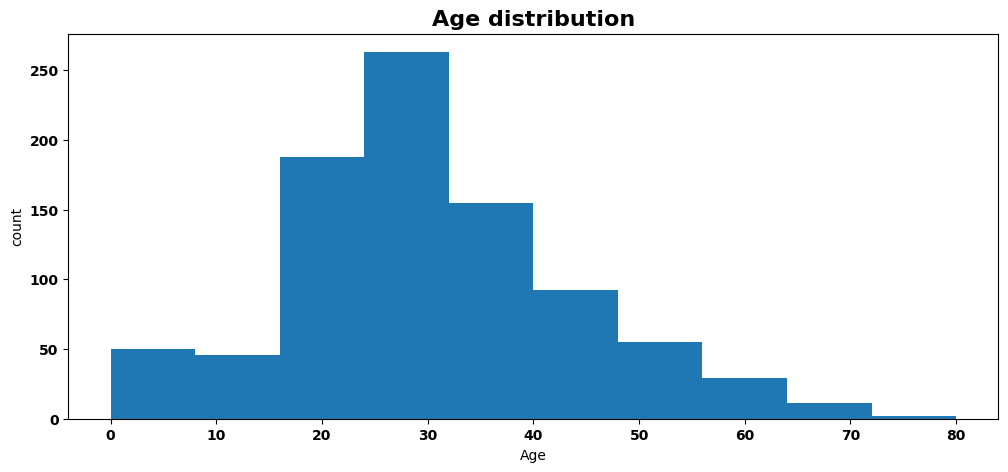

In [ ]:
#step 7:eda
plt.figure(figsize=(12,5))
plt.title("Age distribution",fontweight="bold",fontsize=16 )
plt.hist(df["Age"],bins=10)
plt.xlabel("Age")
plt.ylabel("count")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()

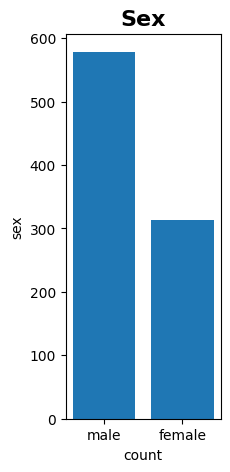

In [ ]:
a=df["Sex"].value_counts()
plt.figure(figsize=(2,5))
plt.bar(a.index,a.values)
plt.title("Sex",fontweight="bold",fontsize=16 )
plt.xlabel("count")
plt.ylabel("sex")
plt.show()


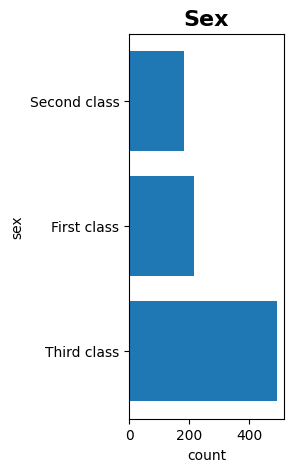

In [ ]:
a=df["Pclass"].value_counts()
plt.figure(figsize=(2,5))
plt.barh(a.index,a.values)
plt.title("Sex",fontweight="bold",fontsize=16 )
plt.xlabel("count")
plt.ylabel("sex")
plt.show()


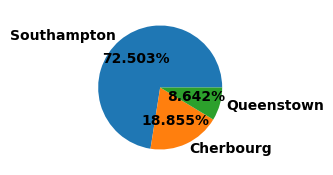

In [ ]:
a=df["Embarked"].value_counts()
plt.figure(figsize=(2,5))
plt.pie(a.values,labels=a.index,autopct="%1.3f%%",textprops={"fontweight":"bold"})
plt.show()


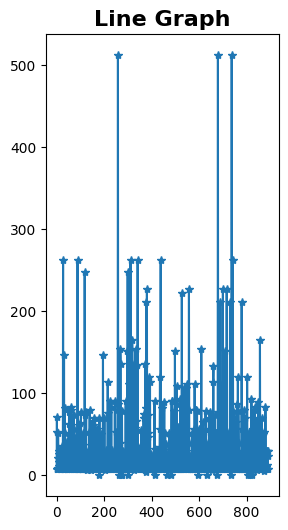

In [ ]:
plt.figure(figsize=(3,6))
plt.title("Line Graph",fontweight="bold",fontsize=16 )
plt.plot(df["Fare"],marker="*")
plt.show()


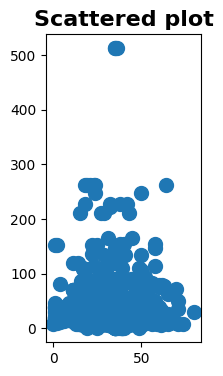

In [ ]:
plt.figure(figsize=(2,4))
plt.title("Scattered plot",fontweight="bold",fontsize=16 )
plt.scatter(df["Age"],df["Fare"],s=100)
plt.show()

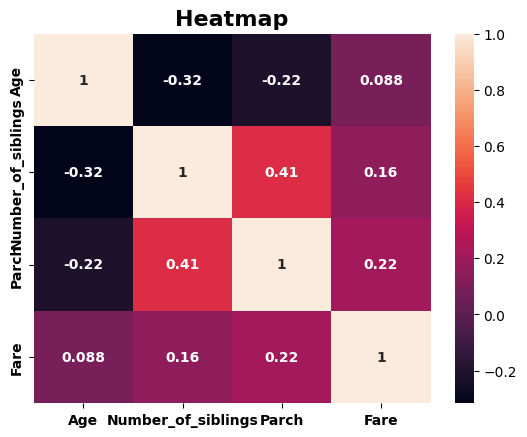

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
a=df.select_dtypes(exclude="object")
b=a.corr()
sns.heatmap(b,annot=True,annot_kws={"fontweight":"bold"})
plt.title("Heatmap",fontweight="bold",fontsize=16 )
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()


In [ ]:
#step 8:label encoding
a=df.select_dtypes(include="object")
for i in a:
  le=LabelEncoder()
  df[i]=le.fit_transform(df[i])
df.head()

,Survived,Pclass,Name,Sex,Age,Number_of_siblings,Parch,Ticket,Fare,Embarked
0,1,2,108,1,22.0,1,0,522,7.2500,2
1,0,0,190,0,38.0,1,0,595,71.2833,0
2,0,2,353,0,26.0,0,0,668,7.9250,2
3,0,0,272,0,35.0,1,0,49,53.1000,2
4,1,2,15,1,35.0,0,0,471,8.0500,2


In [ ]:
#step 9:fit x and y
from sklearn.model_selection import train_test_split
X=df.drop(columns=["Survived","Name","Ticket"],axis=1)
y=df["Survived"]

In [ ]:
X

,Pclass,Sex,Age,Number_of_siblings,Parch,Fare,Embarked
0,2,1,22.0,1,0,7.2500,2
1,0,0,38.0,1,0,71.2833,0
2,2,0,26.0,0,0,7.9250,2
3,0,0,35.0,1,0,53.1000,2
4,2,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,1,1,27.0,0,0,13.0000,2
887,0,0,19.0,0,0,30.0000,2
888,2,0,17.0,1,2,23.4500,2
889,0,1,26.0,0,0,30.0000,0


In [ ]:
y

,Survived
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,1
889,0


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#step 10:scaling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train

array([[ 0.84505322, -1.37207547, -1.53007859, ...,  0.80093686,
        -0.35640747, -1.88710342],
       [-1.52375737,  0.72882288,  0.85946788, ..., -0.46351335,
        -0.13778811,  0.59647816],
       [-1.52375737,  0.72882288,  1.22152037, ..., -0.46351335,
        -0.15164771,  0.59647816],
       ...,
       [ 0.84505322,  0.72882288, -0.37151061, ..., -0.46351335,
        -0.50506753, -0.64531263],
       [ 0.84505322,  0.72882288, -0.00945811, ..., -0.46351335,
        -0.51471975,  0.59647816],
       [ 0.84505322, -1.37207547, -0.8059736 , ..., -0.46351335,
        -0.49888021,  0.59647816]])

In [ ]:
#step 11:train classification modal
modal=LogisticRegression()


In [ ]:
modal.fit(X_train,y_train)

LogisticRegression()

In [ ]:
#step 12:predict model
y_pred=modal.predict(X_test)

In [ ]:
#step 13: modal accuracy
print(f'accuracy score: {accuracy_score(y_test,y_pred):.2f}')


accuracy score: 0.83


In [ ]:
#step 14: model evaluation
print('accuracy score:\n',confusion_matrix(y_test,y_pred))
print("\nclassification report:\n",classification_report(y_test,y_pred))

accuracy score:
 [[51 18]
 [13 97]]

classification report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77        69
           1       0.84      0.88      0.86       110

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [ ]:
print("confusion matrix:",confusion_matrix(y_test,y_pred))

confusion matrix: [[51 18]
 [13 97]]


In [ ]:
print("classification report:",classification_report(y_test,y_pred))

classification report:               precision    recall  f1-score   support

           0       0.80      0.74      0.77        69
           1       0.84      0.88      0.86       110

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.83       179



In [ ]:
modal2=DecisionTreeClassifier()
modal2.fit(X_train,y_train)
y_pred=modal2.predict(X_test)
print(f'accuracy score: {accuracy_score(y_test,y_pred):.2f}')

accuracy score: 0.72


In [ ]:
modal3=RandomForestClassifier()
modal3.fit(X_train,y_train)
y_pred=modal3.predict(X_test)
print(f'accuracy score: {accuracy_score(y_test,y_pred):.2f}')


accuracy score: 0.81
